# Prozesszeitreihenanalyse am Beispiel eines offenen Rührkessels

In diesem Notebook untersuchen wir synthetische Prozesszeitreihen eines einfachen offenen Rührkessels mit zwei Stellgrößen und zwei Messgrößen.

Der Fokus liegt nicht auf Forecasting oder komplexen ML-Modellen, sondern auf explorativer Zeitreihenanalyse:

- Zeitindex, Abtastzeit und Datenqualität prüfen
- Resampling, gleitende Mittelwerte und Lag-Features verstehen
- Autokorrelation und partielle Autokorrelation interpretieren
- Cross-Correlation zur Analyse von Verzögerungen und Totzeiten nutzen
- periodische Strukturen vorsichtig untersuchen
- eine Zeitreihe mit STL zerlegen
- MSTL als Erweiterung für mehrere periodische Anteile kennenlernen
- Residuen prüfen: Welche Struktur ist nach der Zerlegung noch enthalten?

Die zentrale diagnostische Frage lautet:

> Welche Struktur ist in der Zeitreihe noch enthalten?


## Lernziele

Nach diesem Notebook können Sie:

- Prozesszeitreihen mit einem Zeitindex in `pandas` organisieren,
- gleichmäßige Abtastung und fehlende Werte prüfen,
- gleitende Mittelwerte und Lag-Features mit `shift()` erzeugen,
- ACF und PACF für einzelne Zeitreihen interpretieren,
- Cross-Correlation zwischen zwei Messkanälen berechnen und Lags interpretieren,
- einschätzen, warum Periodogramme bei sprungdominierten Prozessdaten schwierig sein können,
- eine Prozesszeitreihe mit STL in Trend, saisonale Komponente und Residuum zerlegen,
- MSTL als Erweiterung für mehrere periodische Anteile anwenden,
- Residuen erneut diagnostizieren und beurteilen, ob noch systematische Struktur vorhanden ist.


## Prozessbeispiel: offener beheizter Rührkessel

Wir betrachten einen vereinfachten offenen Rührkessel.

Der Behälter wird kontinuierlich mit einer kälteren Flüssigkeit beschickt und über eine Heizung erwärmt. Der Rührer sorgt für eine näherungsweise homogene Temperatur im Behälter.

Die simulierten Signale sind:

| Symbol | Größe | Bedeutung |
|---|---|---|
| `u1` | Heizleistung | Stellgröße in % |
| `u2` | Zulaufventil | Stellgröße in % |
| `y1` | Temperatur | Messgröße in °C |
| `y2` | Füllstand | Messgröße in % |

Erwartete Wirkzusammenhänge:

| Zusammenhang | Erwartung | Begründung |
|---|---|---|
| `u1 → y1` | stark positiv | Mehr Heizleistung erhöht die Temperatur. |
| `u2 → y2` | stark positiv | Mehr Zulauf erhöht den Füllstand. |
| `u2 → y1` | negativ | Mehr kalter Zulauf kühlt den Behälter. |
| `u1 → y2` | schwach | Heizen beeinflusst den Füllstand kaum direkt. |
| `y2 ↔ y1` | eher negativ | Höherer Füllstand entsteht durch mehr kalten Zulauf und kann mit niedrigerer Temperatur einhergehen. |

Die Daten sind bewusst synthetisch. Dadurch sind Totzeiten, Trägheiten, Trends, Zyklen und Rauschen gezielt einstellbar.

## 1. Setup

Wir verwenden in diesem Notebook nur Standardwerkzeuge für eine erste Zeitreihenanalyse:

- `numpy` für numerische Berechnungen
- `pandas` für Zeitindex und Tabellen
- `matplotlib` für Visualisierungen
- `scipy.signal.periodogram` nur als vorsichtigen, optionalen Diagnoseversuch
- `statsmodels` für ACF, PACF, STL und optional MSTL


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import periodogram
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

try:
    from statsmodels.tsa.seasonal import MSTL
    MSTL_AVAILABLE = True
except Exception:
    MSTL_AVAILABLE = False

# Reproduzierbarkeit
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Plot-Grundkonfiguration
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print(f"MSTL verfügbar: {MSTL_AVAILABLE}")


MSTL verfügbar: True


## 2. Hilfsfunktionen

Die folgenden Funktionen erzeugen einfache Prozesssignale und unterstützen die Diagnose.

Wichtig ist die Vorzeichenkonvention für die Cross-Correlation:

- positiver Lag: Signal `b` folgt Signal `a`
- negativer Lag: Signal `b` liegt vor Signal `a`

Beispiel: Ein positiver Lag bei `u1 → y1` bedeutet, dass die Temperatur `y1` der Heizleistung `u1` zeitverzögert folgt.

In [7]:
def make_block_signal(values, block_size, n_samples):
    """Erzeugt ein stufenförmiges Signal aus festen Blockwerten."""
    signal = np.repeat(values, block_size)
    return signal[:n_samples].astype(float)


def first_order_plus_dead_time(u_delta, gain, tau, delay, sample_time=1.0):
    """
    Einfache diskrete Näherung eines FOPDT-Verhaltens.

    u_delta: Eingangssignal als Abweichung vom Arbeitspunkt
    gain: statische Verstärkung
    tau: Zeitkonstante in Minuten
    delay: Totzeit in Samples
    sample_time: Abtastzeit in Minuten
    """
    n = len(u_delta)
    y_delta = np.zeros(n)
    alpha = sample_time / (tau + sample_time)

    for k in range(1, n):
        delayed_index = k - delay

        # Vor Beginn der Totzeit wird der erste Eingangswert verwendet.
        if delayed_index >= 0:
            u_eff = u_delta[delayed_index]
        else:
            u_eff = u_delta[0]

        y_delta[k] = y_delta[k - 1] + alpha * (gain * u_eff - y_delta[k - 1])

    return y_delta


def centered_rolling_mean(series, window):
    """
    Zentrierter gleitender Mittelwert für die explorative Darstellung.

    Hinweis:
    - Zentriert bedeutet: Der Mittelwert wird zeitlich in die Mitte des Fensters gelegt.
    - Dadurch entsteht im Plot kein scheinbarer Nachlauf.
    - Für Echtzeit-Anwendungen wäre dagegen ein nicht-zentrierter Mittelwert nötig.
    """
    min_periods = max(3, window // 2)
    return series.rolling(window=window, center=True, min_periods=min_periods).mean()


def symmetric_cross_correlation(a, b, max_lag):
    """
    Berechnet eine symmetrische Cross-Correlation für negative und positive Lags.

    Interpretation:
    - lag > 0: b folgt a
    - lag < 0: b liegt vor a
    """
    a = np.asarray(a)
    b = np.asarray(b)

    lags = np.arange(-max_lag, max_lag + 1)
    corr_values = []

    for lag in lags:
        if lag < 0:
            x = a[-lag:]
            y = b[:lag]
        elif lag > 0:
            x = a[:-lag]
            y = b[lag:]
        else:
            x = a
            y = b

        if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
            corr_values.append(np.nan)
        else:
            corr_values.append(np.corrcoef(x, y)[0, 1])

    return lags, np.array(corr_values)


def find_relevant_lag(lags, corr_values, mode="abs", only_positive_lags=True):
    """
    Ermittelt einen relevanten Lag aus einer CCF.

    mode="max": stärkste positive Korrelation
    mode="min": stärkste negative Korrelation
    mode="abs": betragsmäßig stärkste Korrelation
    """
    lags = np.asarray(lags)
    corr_values = np.asarray(corr_values)

    mask = ~np.isnan(corr_values)
    if only_positive_lags:
        mask = mask & (lags >= 0)

    lags_sel = lags[mask]
    corr_sel = corr_values[mask]

    if len(lags_sel) == 0:
        return np.nan, np.nan

    if mode == "max":
        idx = np.argmax(corr_sel)
    elif mode == "min":
        idx = np.argmin(corr_sel)
    else:
        idx = np.argmax(np.abs(corr_sel))

    return lags_sel[idx], corr_sel[idx]


def plot_ccf(a, b, name_a, name_b, max_lag=100, mode="abs"):
    """Visualisiert die Cross-Correlation zweier Signale."""
    lags, corr_values = symmetric_cross_correlation(a, b, max_lag=max_lag)
    best_lag, best_corr = find_relevant_lag(lags, corr_values, mode=mode)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.stem(lags, corr_values, basefmt=" ")
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(best_lag, linestyle="--", linewidth=1)
    ax.set_title(f"Cross-Correlation: {name_a} → {name_b}")
    ax.set_xlabel("Lag in Samples bzw. Minuten")
    ax.set_ylabel("Korrelationskoeffizient")
    ax.text(
        0.02,
        0.95,
        f"relevanter Lag: {best_lag:.0f} min\nKorrelation: {best_corr:.2f}",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", alpha=0.15),
    )
    plt.show()

    return best_lag, best_corr


def plot_periodogram_for_series(
    series,
    sample_time_min=1.0,
    min_period_min=20,
    max_period_min=300,
    detrend_window=241,
    title="Periodogramm",
):
    """
    Vorsichtige Periodogramm-Diagnose mit Periodenachse.

    Für sprungdominierte Prozessdaten wird zuerst ein langsamer zentrierter
    gleitender Mittelwert abgezogen. Das ist keine allgemeine Pflichtmethode,
    sondern eine didaktische Vorbereitung, damit periodische Anteile sichtbarer werden.
    """
    s = pd.Series(series).astype(float).interpolate(limit_direction="both")

    slow_trend = centered_rolling_mean(s, window=detrend_window).bfill().ffill()
    x = (s - slow_trend).dropna().to_numpy()
    x = x - np.mean(x)

    fs = 1.0 / sample_time_min
    freqs, power = periodogram(x, fs=fs, window="hann", scaling="density")

    # Frequenz 0 entspricht der Gleichkomponente und wird nicht als Periode dargestellt.
    mask = freqs > 0
    freqs = freqs[mask]
    power = power[mask]

    periods = 1.0 / freqs
    mask = (periods >= min_period_min) & (periods <= max_period_min)

    periods = periods[mask]
    power = power[mask]

    order = np.argsort(periods)
    periods = periods[order]
    power = power[order]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(periods, power)
    ax.axvline(SHORT_CYCLE_PERIOD_MIN, linestyle="--", linewidth=1, label="eingebaute kurze Periode")
    ax.axvline(LONG_CYCLE_PERIOD_MIN, linestyle="--", linewidth=1, label="eingebaute lange Periode")
    ax.set_title(title)
    ax.set_xlabel("Periode in Minuten")
    ax.set_ylabel("Leistungsdichte")
    ax.legend()
    plt.show()

    peak_table = (
        pd.DataFrame({"Periode_min": periods, "Leistungsdichte": power})
        .sort_values("Leistungsdichte", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    return peak_table


def residual_diagnostics(residual, max_lag=80, title="Residualdiagnose"):
    """Diagnose des Residuums mit Zeitreihenplot, ACF und PACF."""
    residual = pd.Series(residual).dropna()

    fig, axes = plt.subplots(3, 1, figsize=(11, 9))

    axes[0].plot(residual.index, residual.values)
    axes[0].set_title(f"{title}: Residuum im Zeitbereich")
    axes[0].set_ylabel("Residuum")

    plot_acf(residual, lags=max_lag, ax=axes[1])
    axes[1].set_title("ACF des Residuums")

    plot_pacf(residual, lags=max_lag, ax=axes[2], method="ywm")
    axes[2].set_title("PACF des Residuums")

    plt.tight_layout()
    plt.show()


def residual_quality_table(residuals):
    """Kompakte Kennzahlen zur Residualdiagnose."""
    rows = []
    for name, values in residuals.items():
        s = pd.Series(values).dropna()
        rows.append(
            {
                "Signal": name,
                "Std": s.std(),
                "mittlere_abs_Abweichung": s.abs().mean(),
                "ACF_Lag_1": s.autocorr(lag=1),
                "ACF_Lag_10": s.autocorr(lag=10),
            }
        )
    return pd.DataFrame(rows)


## 3. Konfiguration des synthetischen Prozesses

Die Simulation ist so gewählt, dass die wichtigsten Zusammenhänge sichtbar werden:

- `u1 → y1`: starke positive Wirkung der Heizleistung auf die Temperatur
- `u2 → y2`: starke positive Wirkung des Zulaufs auf den Füllstand
- `u2 → y1`: negative Wirkung des kalten Zulaufs auf die Temperatur
- `u1 → y2`: nur schwacher indirekter Zusammenhang

Zusätzlich werden zwei periodische Störungen eingebaut:

- eine kurze periodische Störung, zum Beispiel ein Betriebs- oder Rührwerkszyklus
- eine längere periodische Störung, zum Beispiel ein Umgebungs- oder Schichtmuster

Die Abtastzeit beträgt 1 Minute. Dadurch entsprechen Lags in Samples direkt Lags in Minuten.


In [9]:
# Allgemeine Simulation
SAMPLE_TIME_MIN = 1.0
N_SAMPLES = 1000

time_index = pd.date_range(
    start="2026-01-01 08:00",
    periods=N_SAMPLES,
    freq=f"{int(SAMPLE_TIME_MIN)}min",
)

# Arbeitspunkte
BASE_U1 = 50.0       # Heizleistung in %
BASE_U2 = 50.0       # Zulaufventil in %
BASE_TEMP = 45.0     # Temperatur in °C
BASE_LEVEL = 50.0    # Füllstand in %

# Dynamik: u1 -> y1
K_U1_Y1 = 0.35
DELAY_U1_Y1 = 8
TAU_U1_Y1 = 35

# Dynamik: u2 -> y1
K_U2_Y1 = -0.18
DELAY_U2_Y1 = 18
TAU_U2_Y1 = 55

# Dynamik: u2 -> y2
K_U2_Y2 = 0.55
DELAY_U2_Y2 = 5
TAU_U2_Y2 = 30

# Trends
TEMP_TREND_PER_MIN = -0.002
LEVEL_TREND_PER_MIN = 0.001

# Zwei periodische Störungen
SHORT_CYCLE_PERIOD_MIN = 60
LONG_CYCLE_PERIOD_MIN = 180

SHORT_CYCLE_PERIOD_SAMPLES = int(SHORT_CYCLE_PERIOD_MIN / SAMPLE_TIME_MIN)
LONG_CYCLE_PERIOD_SAMPLES = int(LONG_CYCLE_PERIOD_MIN / SAMPLE_TIME_MIN)

# Für die spätere einfache STL-Zerlegung wird zunächst nur die lange Periode verwendet.
CYCLE_PERIOD_MIN = LONG_CYCLE_PERIOD_MIN
CYCLE_PERIOD_SAMPLES = LONG_CYCLE_PERIOD_SAMPLES

TEMP_SHORT_CYCLE_AMPLITUDE = 0.45
TEMP_LONG_CYCLE_AMPLITUDE = 1.2

LEVEL_SHORT_CYCLE_AMPLITUDE = 0.55
LEVEL_LONG_CYCLE_AMPLITUDE = 1.5

# Messrauschen
TEMP_NOISE_STD = 0.3
LEVEL_NOISE_STD = 0.8

print(f"Kurze Periode: {SHORT_CYCLE_PERIOD_SAMPLES} Samples")
print(f"Lange Periode: {LONG_CYCLE_PERIOD_SAMPLES} Samples")


Kurze Periode: 60 Samples
Lange Periode: 180 Samples


## 4. Stellgrößen erzeugen

Die Stellgrößen werden als stufenförmige Betriebsfahrweise erzeugt.

Das entspricht zum Beispiel manuellen oder automatischen Änderungen an Heizleistung und Zulaufventil. Die Änderungen von `u1` und `u2` erfolgen nicht gleichzeitig. Das hilft später bei der Interpretation der Cross-Correlation.

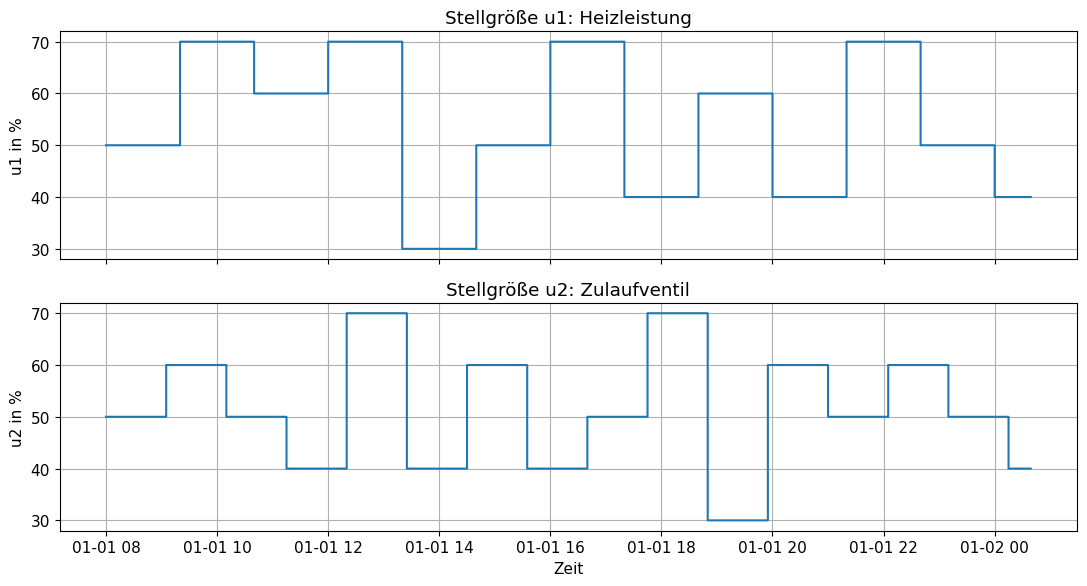

In [11]:
# Stufenwerte für die Heizleistung u1
u1_values = [50, 70, 60, 70, 30, 50, 70, 40, 60, 40, 70, 50, 40]
u1_heater_pct = make_block_signal(u1_values, block_size=80, n_samples=N_SAMPLES)

# Stufenwerte für den Zulauf u2
u2_values = [50, 60, 50, 40, 70, 40, 60, 40, 50, 70, 30, 60, 50, 60, 50, 40]
u2_inflow_pct = make_block_signal(u2_values, block_size=65, n_samples=N_SAMPLES)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].step(time_index, u1_heater_pct, where="post")
axes[0].set_title("Stellgröße u1: Heizleistung")
axes[0].set_ylabel("u1 in %")

axes[1].step(time_index, u2_inflow_pct, where="post")
axes[1].set_title("Stellgröße u2: Zulaufventil")
axes[1].set_ylabel("u2 in %")
axes[1].set_xlabel("Zeit")

plt.tight_layout()
plt.show()

## 5. Messgrößen erzeugen

Die Messgrößen werden aus einfachen verzögerten und trägen Prozessantworten aufgebaut.

Für die Temperatur gilt vereinfacht:

$$
y_1(t) =
y_{1,0}
+ g_{11}(t)
+ g_{12}(t)
+ T_1(t)
+ S_{1,\mathrm{kurz}}(t)
+ S_{1,\mathrm{lang}}(t)
+ \varepsilon_1(t)
$$

Für den Füllstand gilt vereinfacht:

$$
y_2(t) =
y_{2,0}
+ g_{22}(t)
+ T_2(t)
+ S_{2,\mathrm{kurz}}(t)
+ S_{2,\mathrm{lang}}(t)
+ \varepsilon_2(t)
$$

Dabei bedeuten:

- $g_{11}(t)$: verzögerte und träge Wirkung der Heizleistung auf die Temperatur
- $g_{12}(t)$: verzögerte und träge Wirkung des kalten Zulaufs auf die Temperatur
- $g_{22}(t)$: verzögerte und träge Wirkung des Zulaufs auf den Füllstand
- $T(t)$: langsamer Trend
- $S(t)$: periodische Störung
- $\varepsilon(t)$: Messrauschen

Die direkte Wirkung von `u1` auf `y2` wird bewusst nicht modelliert. Dadurch entsteht ein Beispiel, bei dem ein Zusammenhang physikalisch nicht erwartet wird.


In [13]:
t = np.arange(N_SAMPLES)

# Eingangssignale als Abweichung vom Arbeitspunkt
du1 = u1_heater_pct - BASE_U1
du2 = u2_inflow_pct - BASE_U2

# Temperaturbeiträge
temp_from_heater = first_order_plus_dead_time(
    du1,
    gain=K_U1_Y1,
    tau=TAU_U1_Y1,
    delay=DELAY_U1_Y1,
    sample_time=SAMPLE_TIME_MIN,
)

temp_from_inflow = first_order_plus_dead_time(
    du2,
    gain=K_U2_Y1,
    tau=TAU_U2_Y1,
    delay=DELAY_U2_Y1,
    sample_time=SAMPLE_TIME_MIN,
)

# Füllstandsbeitrag
level_from_inflow = first_order_plus_dead_time(
    du2,
    gain=K_U2_Y2,
    tau=TAU_U2_Y2,
    delay=DELAY_U2_Y2,
    sample_time=SAMPLE_TIME_MIN,
)

# Langsame Trends
temp_trend = TEMP_TREND_PER_MIN * t
level_trend = LEVEL_TREND_PER_MIN * t

# Periodische Störungen
temp_cycle_short = TEMP_SHORT_CYCLE_AMPLITUDE * np.sin(
    2 * np.pi * t / SHORT_CYCLE_PERIOD_SAMPLES + 0.3
)
temp_cycle_long = TEMP_LONG_CYCLE_AMPLITUDE * np.sin(
    2 * np.pi * t / LONG_CYCLE_PERIOD_SAMPLES
)

level_cycle_short = LEVEL_SHORT_CYCLE_AMPLITUDE * np.sin(
    2 * np.pi * t / SHORT_CYCLE_PERIOD_SAMPLES + 1.2
)
level_cycle_long = LEVEL_LONG_CYCLE_AMPLITUDE * np.sin(
    2 * np.pi * t / LONG_CYCLE_PERIOD_SAMPLES + 0.8
)

# Messrauschen
temp_noise = rng.normal(0, TEMP_NOISE_STD, N_SAMPLES)
level_noise = rng.normal(0, LEVEL_NOISE_STD, N_SAMPLES)

# Messgrößen
y1_temperature_degC = (
    BASE_TEMP
    + temp_from_heater
    + temp_from_inflow
    + temp_trend
    + temp_cycle_short
    + temp_cycle_long
    + temp_noise
)

y2_level_pct = (
    BASE_LEVEL
    + level_from_inflow
    + level_trend
    + level_cycle_short
    + level_cycle_long
    + level_noise
)

# DataFrame
df = pd.DataFrame(
    {
        "u1_heater_pct": u1_heater_pct,
        "u2_inflow_pct": u2_inflow_pct,
        "y1_temperature_degC": y1_temperature_degC,
        "y2_level_pct": y2_level_pct,
    },
    index=time_index,
)

df.head()


,u1_heater_pct,u2_inflow_pct,y1_temperature_degC,y2_level_pct
2026-01-01 08:00:00,50.0,50.0,45.224399,51.541230
2026-01-01 08:01:00,50.0,50.0,44.905077,51.060067
2026-01-01 08:02:00,50.0,50.0,45.524303,51.359590
2026-01-01 08:03:00,50.0,50.0,45.660926,52.238624
2026-01-01 08:04:00,50.0,50.0,44.870041,51.766765


## 6. Erste Visualisierung

Zuerst betrachten wir alle Signale im Zeitbereich.

Leitfragen:

- Wo sind Stellgrößenänderungen sichtbar?
- Reagieren die Messgrößen sofort oder verzögert?
- Welche Messgröße reagiert auf welche Stellgröße?
- Sind Temperatur und Füllstand ähnlich oder eher gegensätzlich?

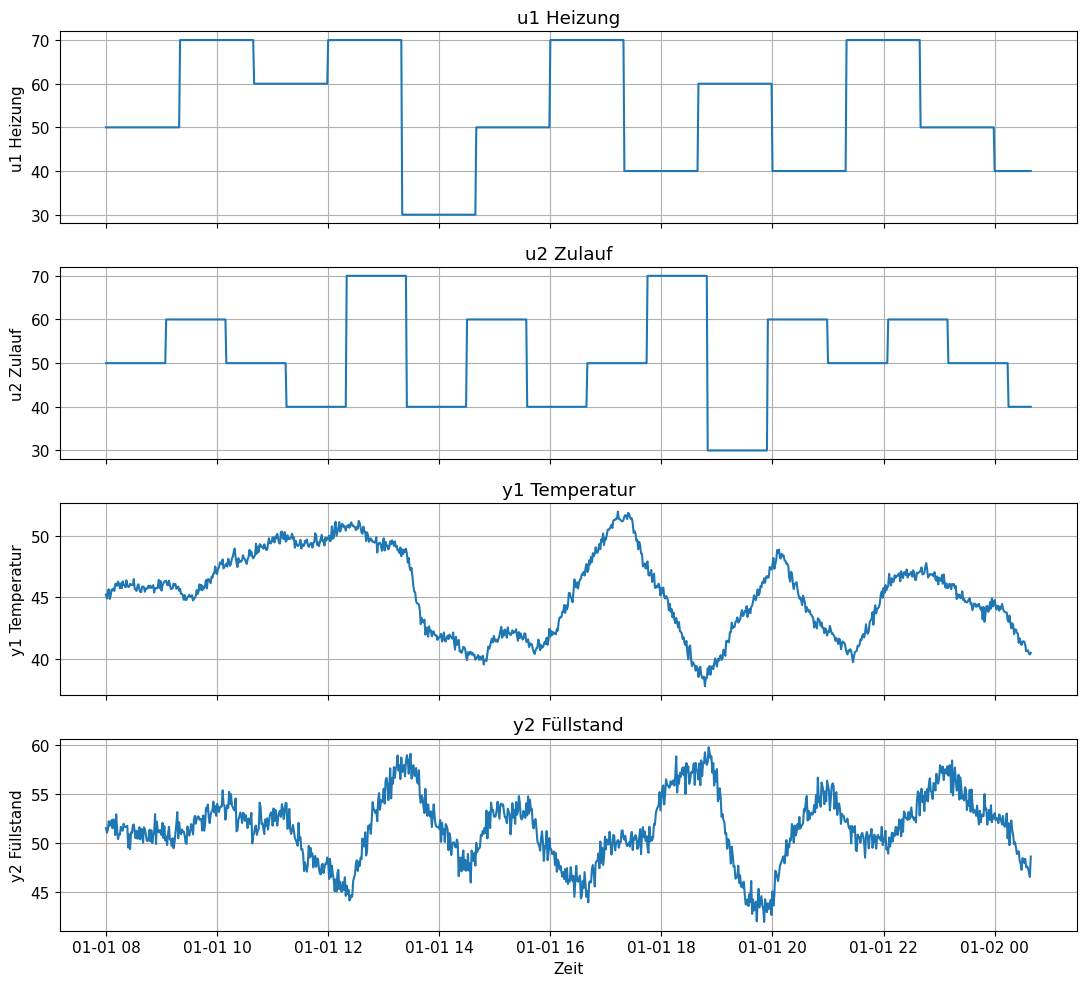

In [15]:
display_names = {
    "u1_heater_pct": "u1 Heizung",
    "u2_inflow_pct": "u2 Zulauf",
    "y1_temperature_degC": "y1 Temperatur",
    "y2_level_pct": "y2 Füllstand",
}

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col])
    ax.set_ylabel(display_names[col])
    ax.set_title(display_names[col])

axes[-1].set_xlabel("Zeit")
plt.tight_layout()
plt.show()

### Korrelationsmatrix der Rohsignale

Die Korrelationsmatrix ist eine erste grobe Orientierung. Sie ersetzt aber keine Zeitreihenanalyse.

Wichtig:

- Korrelation berücksichtigt zunächst keine Verzögerung.
- Trends und Zyklen können Korrelationen verstärken oder verfälschen.
- Korrelation ist nicht automatisch Kausalität.

In [17]:
corr_matrix = df.corr()
corr_matrix

,u1_heater_pct,u2_inflow_pct,y1_temperature_degC,y2_level_pct
u1_heater_pct,1.000000,0.006917,0.408350,-0.246698
u2_inflow_pct,0.006917,1.000000,0.150682,0.418240
y1_temperature_degC,0.408350,0.150682,1.000000,-0.202260
y2_level_pct,-0.246698,0.418240,-0.202260,1.000000


## 7. Zeitindex und Datenqualität prüfen

Viele Zeitreihenmethoden setzen einen sauberen Zeitindex voraus.

Wir prüfen hier:

- Ist der Index monoton sortiert?
- Gibt es fehlende Werte?
- Sind die Zeitabstände konstant?

Hinweis: Klassische FFT- und Periodogramm-Methoden setzen normalerweise eine gleichmäßige Abtastung voraus. Bei Prozessdaten kommt zusätzlich hinzu, dass Sprünge, Trends und Einschwingvorgänge die Frequenzanalyse stark überlagern können.


In [19]:
# Prüfen, ob der Zeitindex sortiert ist
is_monotonic = df.index.is_monotonic_increasing

# Fehlende Werte je Spalte
missing_values = df.isna().sum()

# Zeitabstände
time_diffs = df.index.to_series().diff().dropna()
unique_time_diffs = time_diffs.value_counts()

print(f"Zeitindex monoton steigend: {is_monotonic}")
print("\nFehlende Werte je Spalte:")
print(missing_values)
print("\nHäufigkeit der Zeitabstände:")
print(unique_time_diffs)

Zeitindex monoton steigend: True

Fehlende Werte je Spalte:
u1_heater_pct          0
u2_inflow_pct          0
y1_temperature_degC    0
y2_level_pct           0
dtype: int64

Häufigkeit der Zeitabstände:
0 days 00:01:00    999
Name: count, dtype: int64


## 8. Resampling und gleitender Mittelwert

Resampling und gleitende Mittelwerte sind einfache Werkzeuge zur Vorverarbeitung.

In diesem Abschnitt wird ein zentrierter gleitender Mittelwert verwendet. Dadurch entsteht in der Darstellung kein sichtbarer zeitlicher Nachlauf.

Wichtiger Hinweis:

- Zentrierter gleitender Mittelwert: gut für Offline-EDA und Visualisierung.
- Nicht-zentrierter gleitender Mittelwert: erforderlich, wenn nur vergangene Werte verwendet werden dürfen, zum Beispiel in Echtzeit.


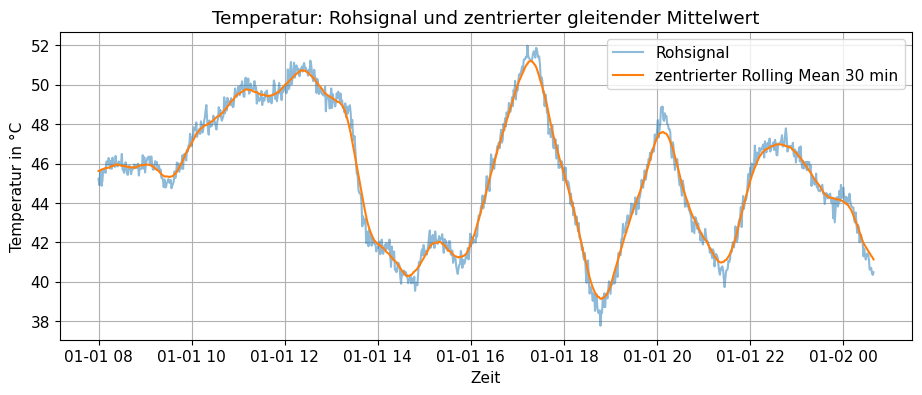

,u1_heater_pct,u2_inflow_pct,y1_temperature_degC,y2_level_pct
2026-01-01 08:00:00,50.0,50.0,45.236949,51.593255
2026-01-01 08:05:00,50.0,50.0,45.516589,52.094286
2026-01-01 08:10:00,50.0,50.0,46.107604,51.283560
2026-01-01 08:15:00,50.0,50.0,45.987523,51.425484
2026-01-01 08:20:00,50.0,50.0,46.002984,51.259222


In [21]:
# Resampling auf 5-Minuten-Mittelwerte
df_5min = df.resample("5min").mean()

# Zentrierter gleitender Mittelwert über 30 Minuten
rolling_window = 30
df_roll_centered = df.apply(lambda col: centered_rolling_mean(col, window=rolling_window))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["y1_temperature_degC"], alpha=0.5, label="Rohsignal")
ax.plot(
    df_roll_centered.index,
    df_roll_centered["y1_temperature_degC"],
    label="zentrierter Rolling Mean 30 min",
)
ax.set_title("Temperatur: Rohsignal und zentrierter gleitender Mittelwert")
ax.set_ylabel("Temperatur in °C")
ax.set_xlabel("Zeit")
ax.legend()
plt.show()

df_5min.head()


## 9. Lag-Features mit `shift()`

Lag-Features sind vergangene Werte einer Zeitreihe.

Sie sind wichtig für viele spätere Modelle, weil Prozesszustände häufig von vergangenen Werten abhängen.

Beispiel:

- `y1_lag_1`: Temperatur vor 1 Minute
- `y1_lag_10`: Temperatur vor 10 Minuten
- `u1_lag_10`: Heizleistung vor 10 Minuten

Die Lags sind hier in Minuten interpretierbar, weil die Abtastzeit 1 Minute beträgt.

In [23]:
df_lag = df.copy()

df_lag["y1_lag_1"] = df_lag["y1_temperature_degC"].shift(1)
df_lag["y1_lag_10"] = df_lag["y1_temperature_degC"].shift(10)
df_lag["u1_lag_10"] = df_lag["u1_heater_pct"].shift(10)
df_lag["u2_lag_20"] = df_lag["u2_inflow_pct"].shift(20)

df_lag[
    [
        "y1_temperature_degC",
        "y1_lag_1",
        "y1_lag_10",
        "u1_heater_pct",
        "u1_lag_10",
        "u2_inflow_pct",
        "u2_lag_20",
    ]
].head(15)

,y1_temperature_degC,y1_lag_1,y1_lag_10,u1_heater_pct,u1_lag_10,u2_inflow_pct,u2_lag_20
2026-01-01 08:00:00,45.224399,NaN,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:01:00,44.905077,45.224399,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:02:00,45.524303,44.905077,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:03:00,45.660926,45.524303,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:04:00,44.870041,45.660926,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:05:00,45.137842,44.870041,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:06:00,45.636122,45.137842,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:07:00,45.567920,45.636122,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:08:00,45.718187,45.567920,NaN,50.0,NaN,50.0,NaN
2026-01-01 08:09:00,45.522871,45.718187,NaN,50.0,NaN,50.0,NaN


### Kurze Interpretationsaufgabe

Betrachten Sie die Tabelle:

1. Warum entstehen am Anfang der Lag-Spalten fehlende Werte?
2. Welche Lag-Features wären für die Temperatur `y1` plausibel?
3. Welche Lag-Features wären für den Füllstand `y2` plausibel?

## 10. ACF und PACF für die Temperatur

Die Autokorrelationsfunktion ACF zeigt, wie stark eine Zeitreihe mit ihren eigenen vergangenen Werten zusammenhängt.

Die partielle Autokorrelationsfunktion PACF zeigt den direkten Zusammenhang zu einem Lag, nachdem kürzere Lags berücksichtigt wurden.

Diagnostische Frage:

> Welche zeitliche Gedächtnisstruktur enthält die Temperaturzeitreihe?

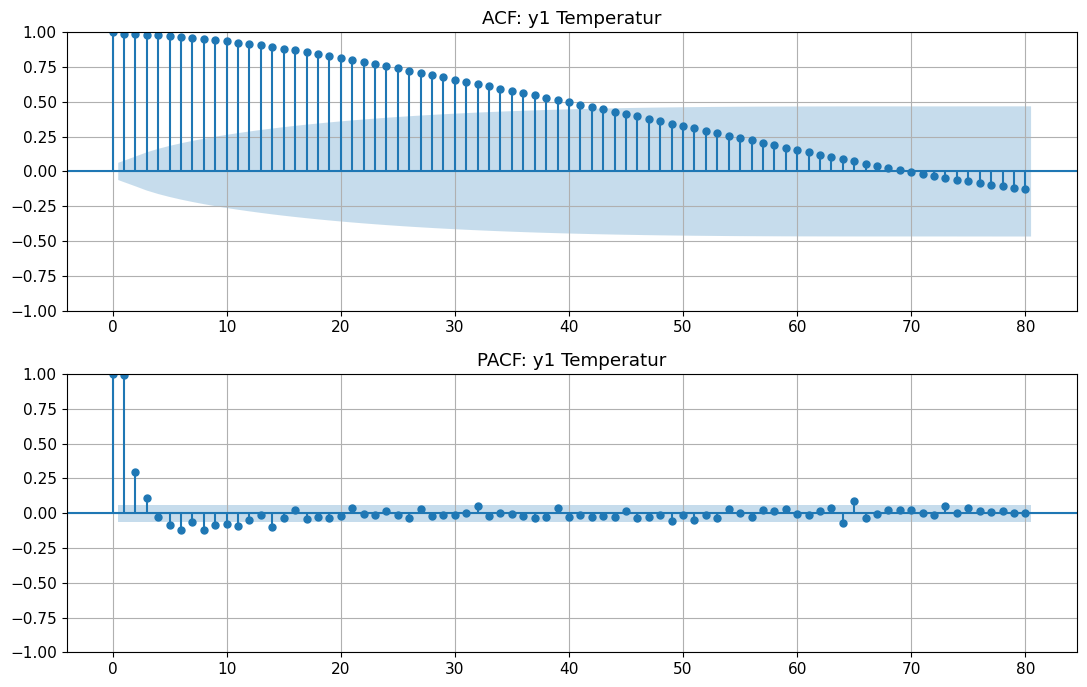

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

plot_acf(df["y1_temperature_degC"], lags=80, ax=axes[0])
axes[0].set_title("ACF: y1 Temperatur")

plot_pacf(df["y1_temperature_degC"], lags=80, ax=axes[1], method="ywm")
axes[1].set_title("PACF: y1 Temperatur")

plt.tight_layout()
plt.show()

## 11. ACF und PACF für den Füllstand

Auch der Füllstand besitzt eine Gedächtnisstruktur, weil der Behälter nicht sofort auf Änderungen des Zulaufs reagiert.

Diagnostische Frage:

> Ist der Füllstand ähnlich stark autokorreliert wie die Temperatur?

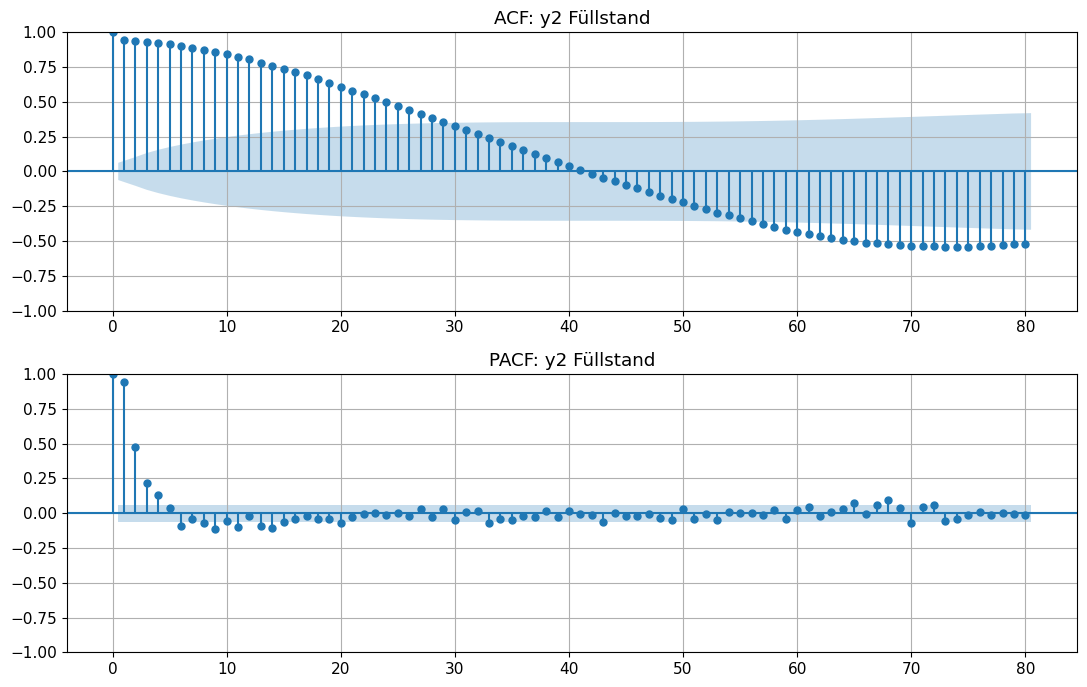

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

plot_acf(df["y2_level_pct"], lags=80, ax=axes[0])
axes[0].set_title("ACF: y2 Füllstand")

plot_pacf(df["y2_level_pct"], lags=80, ax=axes[1], method="ywm")
axes[1].set_title("PACF: y2 Füllstand")

plt.tight_layout()
plt.show()

## 12. Cross-Correlation zwischen Stellgrößen und Messgrößen

Jetzt prüfen wir die verzögerten Zusammenhänge zwischen Stellgrößen und Messgrößen.

Erwartung aus dem Prozessbeispiel:

- `u1 → y1`: deutlich positiv
- `u2 → y2`: deutlich positiv
- `u2 → y1`: negativ, weil kalter Zulauf die Temperatur senkt
- `u1 → y2`: kein direkter physikalischer Effekt

Wichtig: Eine kleine oder mittlere Cross-Correlation bei `u1 → y2` wäre hier kein Beleg für Kausalität. Sie kann durch gemeinsame Betriebsmuster, periodische Störungen oder zufällige Überlagerungen entstehen.


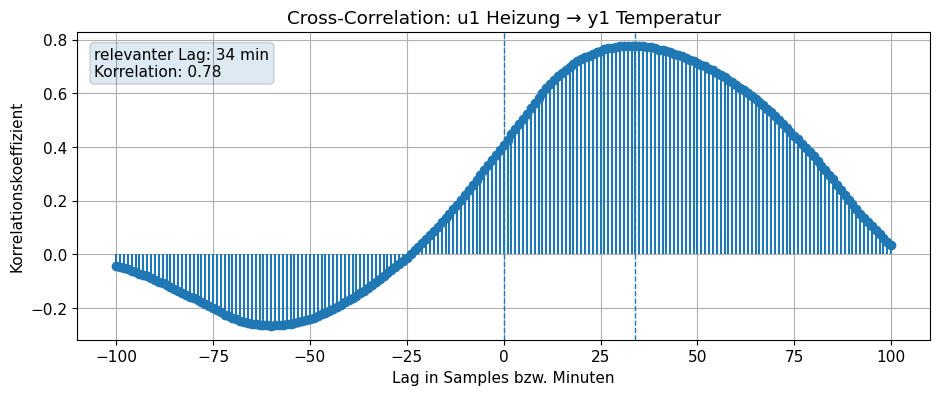

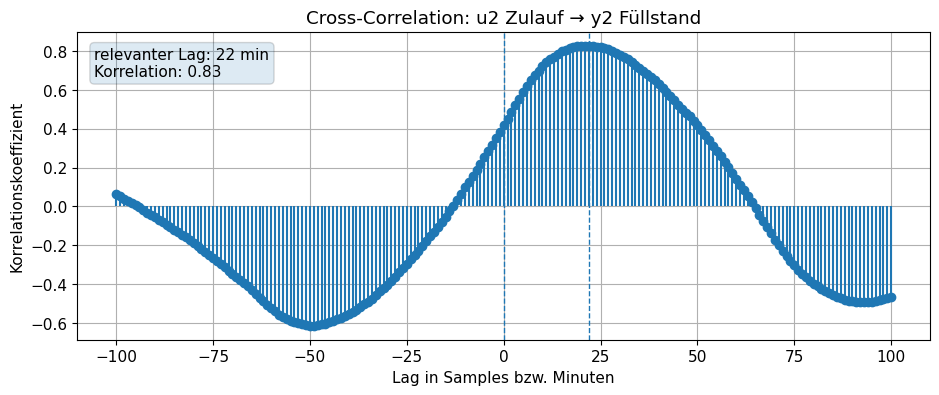

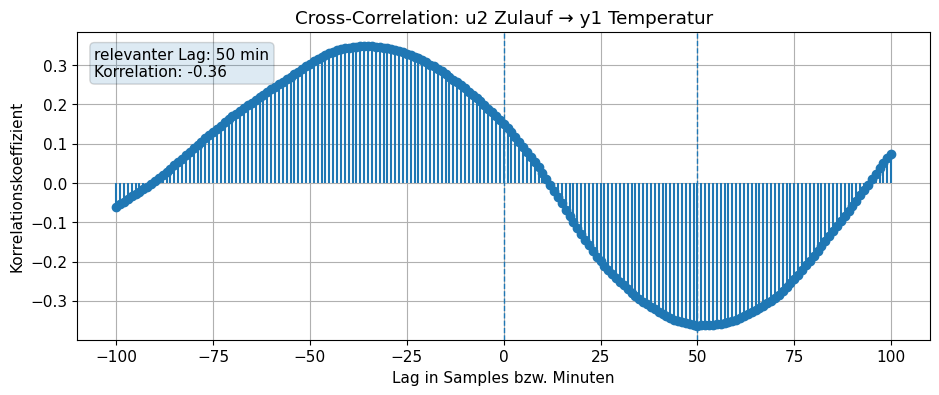

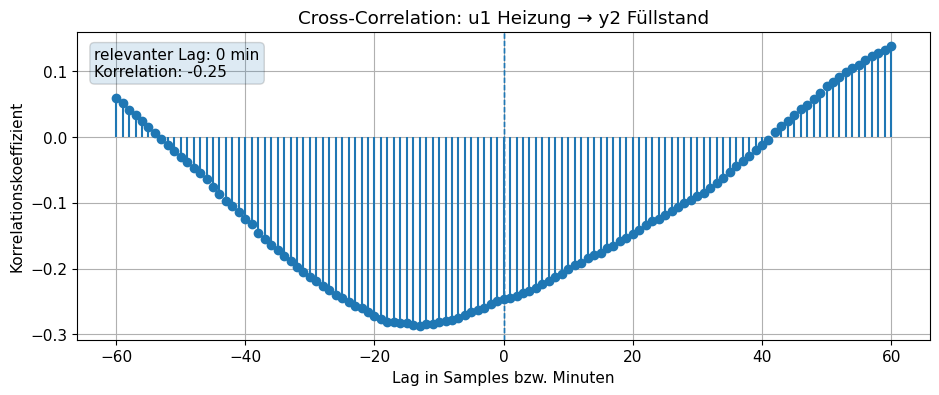

In [30]:
MAX_LAG = 100

lag_u1_y1, corr_u1_y1 = plot_ccf(
    df["u1_heater_pct"],
    df["y1_temperature_degC"],
    "u1 Heizung",
    "y1 Temperatur",
    max_lag=MAX_LAG,
    mode="max",
)

lag_u2_y2, corr_u2_y2 = plot_ccf(
    df["u2_inflow_pct"],
    df["y2_level_pct"],
    "u2 Zulauf",
    "y2 Füllstand",
    max_lag=MAX_LAG,
    mode="max",
)

lag_u2_y1, corr_u2_y1 = plot_ccf(
    df["u2_inflow_pct"],
    df["y1_temperature_degC"],
    "u2 Zulauf",
    "y1 Temperatur",
    max_lag=MAX_LAG,
    mode="min",
)

# Für den physikalisch nicht erwarteten Zusammenhang wird ein kleinerer Lagbereich gezeigt.
# Das vermeidet, dass ein weit entfernter Randwert als scheinbar wichtiger Effekt interpretiert wird.
lag_u1_y2, corr_u1_y2 = plot_ccf(
    df["u1_heater_pct"],
    df["y2_level_pct"],
    "u1 Heizung",
    "y2 Füllstand",
    max_lag=60,
    mode="abs",
)


## 13. Cross-Correlation zwischen den Messgrößen

Jetzt betrachten wir den Zusammenhang zwischen Füllstand und Temperatur.

Physikalisch ist hier wichtig:

Der Füllstand verursacht die Temperaturänderung nicht direkt. Beide Größen hängen aber über den Zulauf zusammen. Mehr Zulauf erhöht den Füllstand und bringt gleichzeitig kältere Flüssigkeit in den Kessel.

Diagnostische Frage:

> Gibt es eine verzögerte Kopplung zwischen den Messwerten?

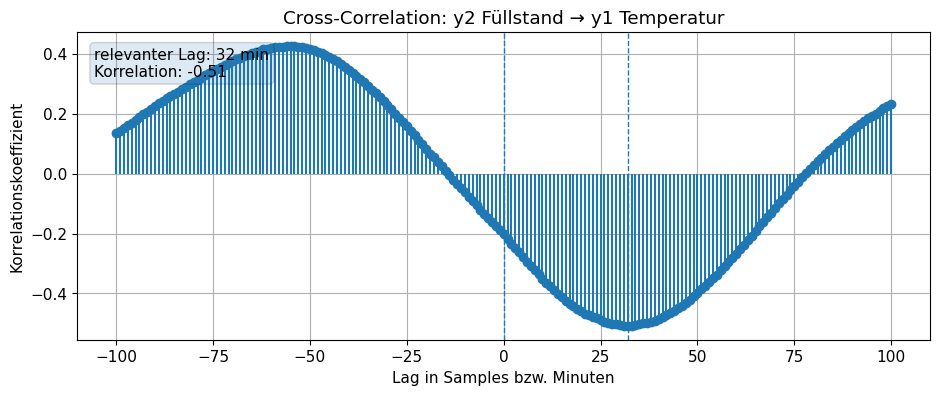

In [32]:
lag_y2_y1, corr_y2_y1 = plot_ccf(
    df["y2_level_pct"],
    df["y1_temperature_degC"],
    "y2 Füllstand",
    "y1 Temperatur",
    max_lag=MAX_LAG,
    mode="min",
)

## 14. Übersicht der gefundenen Lags

Die folgende Tabelle fasst die CCF-Diagnose zusammen.

Die gefundenen Lags müssen nicht exakt den eingebauten Totzeiten entsprechen. Die Cross-Correlation reagiert auch auf Trägheit, Rauschen, Trends, Zyklen und die konkrete Betriebsfahrweise.

In [34]:
ccf_summary = pd.DataFrame(
    [
        {
            "Paar": "u1 Heizung → y1 Temperatur",
            "erwartetes Vorzeichen": "+",
            "relevanter Lag [min]": lag_u1_y1,
            "Korrelation": corr_u1_y1,
            "Interpretation": "Haupteffekt der Heizung",
        },
        {
            "Paar": "u2 Zulauf → y2 Füllstand",
            "erwartetes Vorzeichen": "+",
            "relevanter Lag [min]": lag_u2_y2,
            "Korrelation": corr_u2_y2,
            "Interpretation": "Haupteffekt des Zulaufs",
        },
        {
            "Paar": "u2 Zulauf → y1 Temperatur",
            "erwartetes Vorzeichen": "-",
            "relevanter Lag [min]": lag_u2_y1,
            "Korrelation": corr_u2_y1,
            "Interpretation": "kalter Zulauf kühlt den Kessel",
        },
        {
            "Paar": "u1 Heizung → y2 Füllstand",
            "erwartetes Vorzeichen": "nahe 0",
            "relevanter Lag [min]": lag_u1_y2,
            "Korrelation": corr_u1_y2,
            "Interpretation": "physikalisch kaum direkter Effekt erwartet",
        },
        {
            "Paar": "y2 Füllstand → y1 Temperatur",
            "erwartetes Vorzeichen": "-",
            "relevanter Lag [min]": lag_y2_y1,
            "Korrelation": corr_y2_y1,
            "Interpretation": "gekoppelte Messwerte über den Zulauf",
        },
    ]
)

ccf_summary

,Paar,erwartetes Vorzeichen,relevanter Lag [min],Korrelation,Interpretation
0,u1 Heizung → y1 Temperatur,+,34,0.777226,Haupteffekt der Heizung
1,u2 Zulauf → y2 Füllstand,+,22,0.828082,Haupteffekt des Zulaufs
2,u2 Zulauf → y1 Temperatur,-,50,-0.363589,kalter Zulauf kühlt den Kessel
3,u1 Heizung → y2 Füllstand,nahe 0,0,-0.246698,physikalisch kaum direkter Effekt erwartet
4,y2 Füllstand → y1 Temperatur,-,32,-0.507892,gekoppelte Messwerte über den Zulauf


### Interpretationsaufgabe

1. Welche zwei Zusammenhänge sind am klarsten erkennbar?
2. Warum ist `u2 → y1` negativ?
3. Warum ist `u1 → y2` deutlich schwächer als `u1 → y1`?
4. Warum darf aus `y2 → y1` nicht automatisch eine direkte Kausalität abgeleitet werden?

## 15. Manuelle Verschiebung zur Plausibilitätsprüfung

Die Cross-Correlation sollte nicht nur numerisch betrachtet werden. Wir verschieben ein Signal um den gefundenen Lag und prüfen visuell, ob die Signale plausibler übereinanderliegen.

Hier wird exemplarisch `u1` gegen `y1` betrachtet.

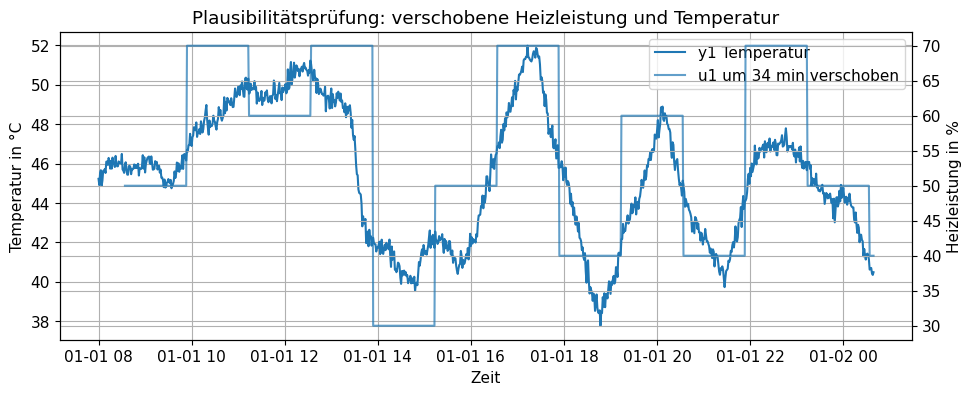

In [37]:
# u1 um den gefundenen Lag verschieben
u1_shifted = df["u1_heater_pct"].shift(int(lag_u1_y1))

fig, ax1 = plt.subplots(figsize=(11, 4))

ax1.plot(df.index, df["y1_temperature_degC"], label="y1 Temperatur")
ax1.set_ylabel("Temperatur in °C")

ax2 = ax1.twinx()
ax2.plot(df.index, u1_shifted, alpha=0.7, label=f"u1 um {int(lag_u1_y1)} min verschoben")
ax2.set_ylabel("Heizleistung in %")

ax1.set_title("Plausibilitätsprüfung: verschobene Heizleistung und Temperatur")
ax1.set_xlabel("Zeit")

# Gemeinsame Legende für beide Achsen
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

## 17. STL-Zerlegung der Temperatur

STL zerlegt eine Zeitreihe in:

- Trend
- saisonale bzw. zyklische Komponente
- Residuum

Hier wird zunächst nur eine Periode verwendet: die längere eingebaute Störung mit 180 Minuten.

Das ist didaktisch absichtlich nicht perfekt. Im Signal befindet sich zusätzlich eine kürzere periodische Störung mit 60 Minuten. Nach der STL-Zerlegung darf im Residuum also noch Struktur übrig bleiben.

Diagnostische Frage:

> Welche Struktur bleibt nach Trend- und Zyklusentfernung im Residuum übrig?


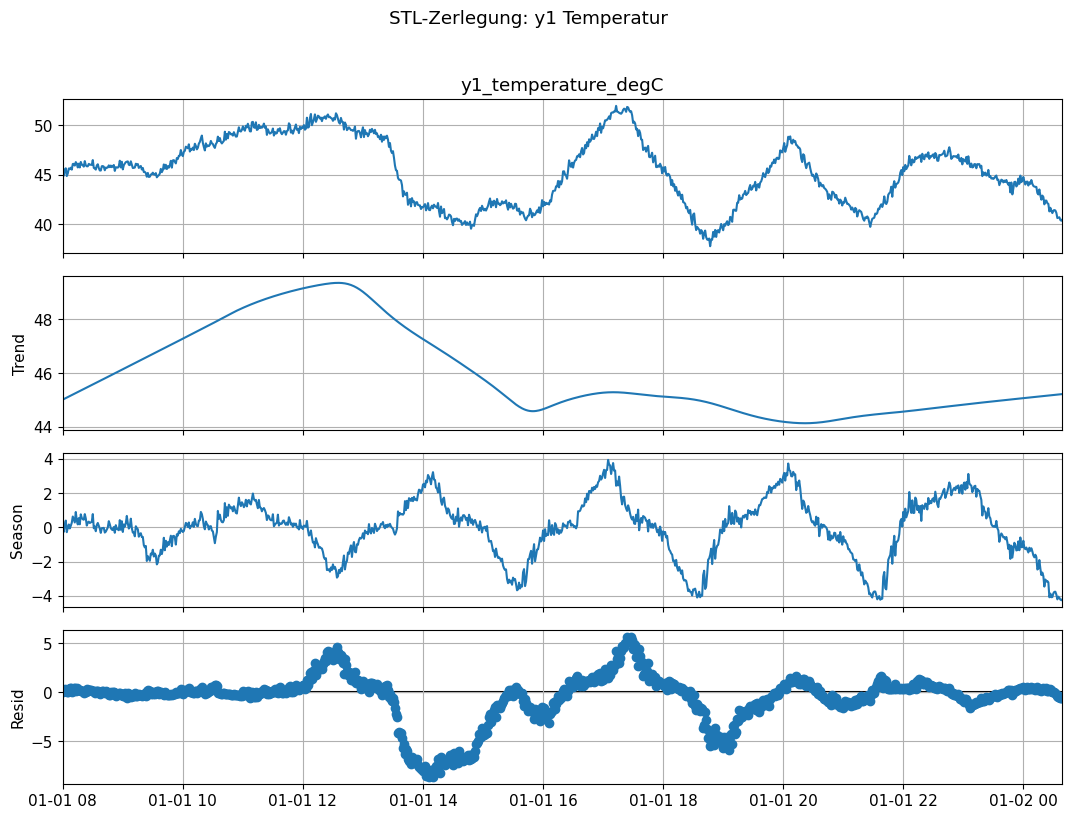

In [42]:
stl_y1 = STL(
    df["y1_temperature_degC"],
    period=CYCLE_PERIOD_SAMPLES,
    robust=True,
)

result_y1 = stl_y1.fit()

fig = result_y1.plot()
fig.set_size_inches(11, 8)
fig.suptitle("STL-Zerlegung: y1 Temperatur", y=1.02)
plt.tight_layout()
plt.show()

## 18. Residualdiagnose der Temperatur

Nach der Zerlegung prüfen wir das Residuum erneut.

Ein gutes Residuum ist nicht nur klein. Es sollte möglichst wenig systematische Struktur enthalten.

Wir prüfen:

- Zeitreihenplot des Residuums
- ACF des Residuums
- PACF des Residuums

Wenn im Residuum noch Autokorrelation sichtbar ist, spricht das für verbleibende zeitliche Struktur.


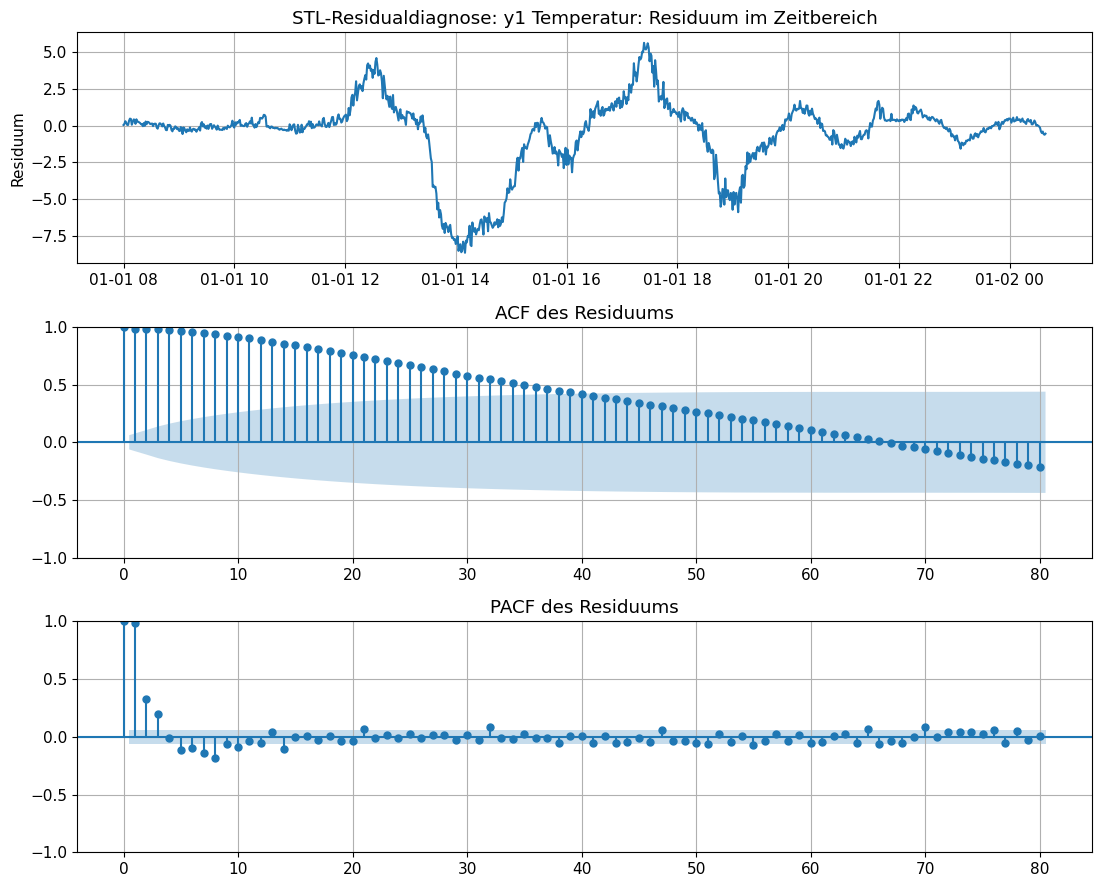

In [44]:
residual_diagnostics(
    result_y1.resid,
    max_lag=80,
    title="STL-Residualdiagnose: y1 Temperatur",
)


## 19. STL-Zerlegung des Füllstands

Jetzt wiederholen wir die Zerlegung für den Füllstand.

Da der Füllstand durch den Zulauf stark beeinflusst wird, kann im Residuum weiterhin Struktur übrig bleiben. Das ist bei Prozessdaten normal und ein wichtiger Diagnosehinweis.

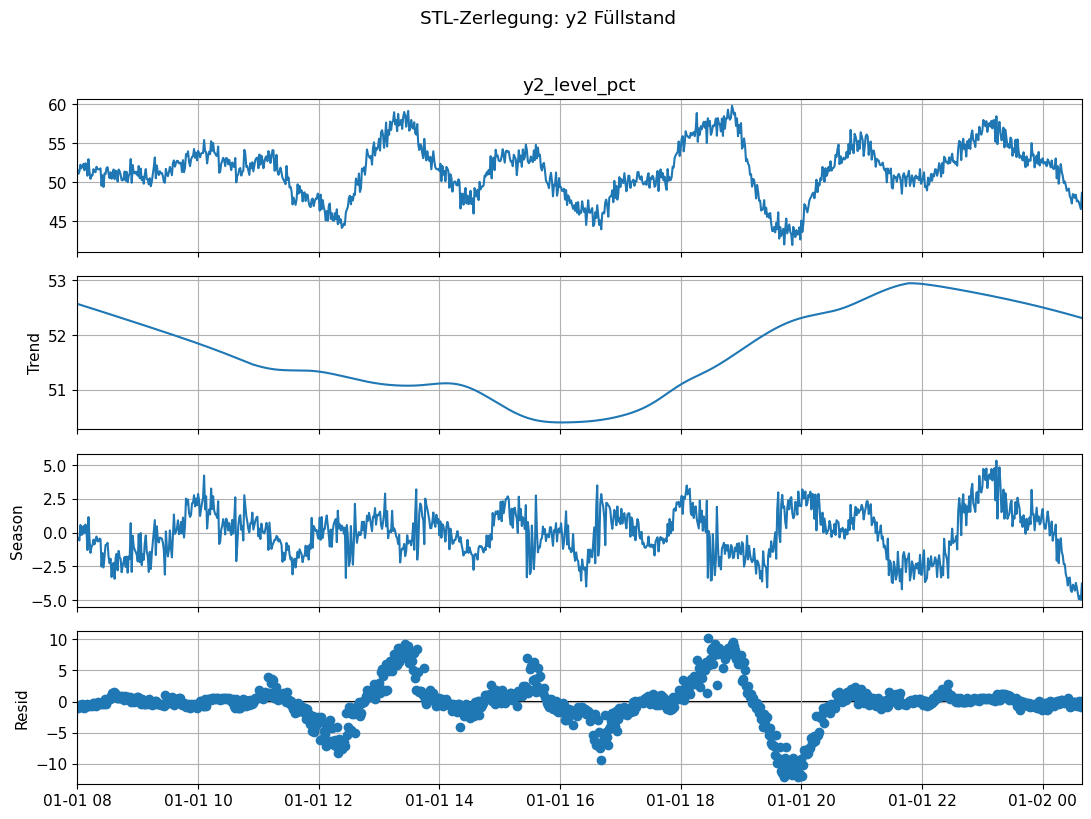

In [46]:
stl_y2 = STL(
    df["y2_level_pct"],
    period=CYCLE_PERIOD_SAMPLES,
    robust=True,
)

result_y2 = stl_y2.fit()

fig = result_y2.plot()
fig.set_size_inches(11, 8)
fig.suptitle("STL-Zerlegung: y2 Füllstand", y=1.02)
plt.tight_layout()
plt.show()

## 20. Residualdiagnose des Füllstands

Auch beim Füllstand wird das Residuum erneut untersucht.

Bei Prozessdaten ist es normal, dass Residuen nach einer einfachen Zerlegung noch Struktur enthalten. Das bedeutet nicht automatisch, dass die Methode falsch ist. Es zeigt vielmehr, dass im Signal mehrere Ursachen gleichzeitig wirken können.


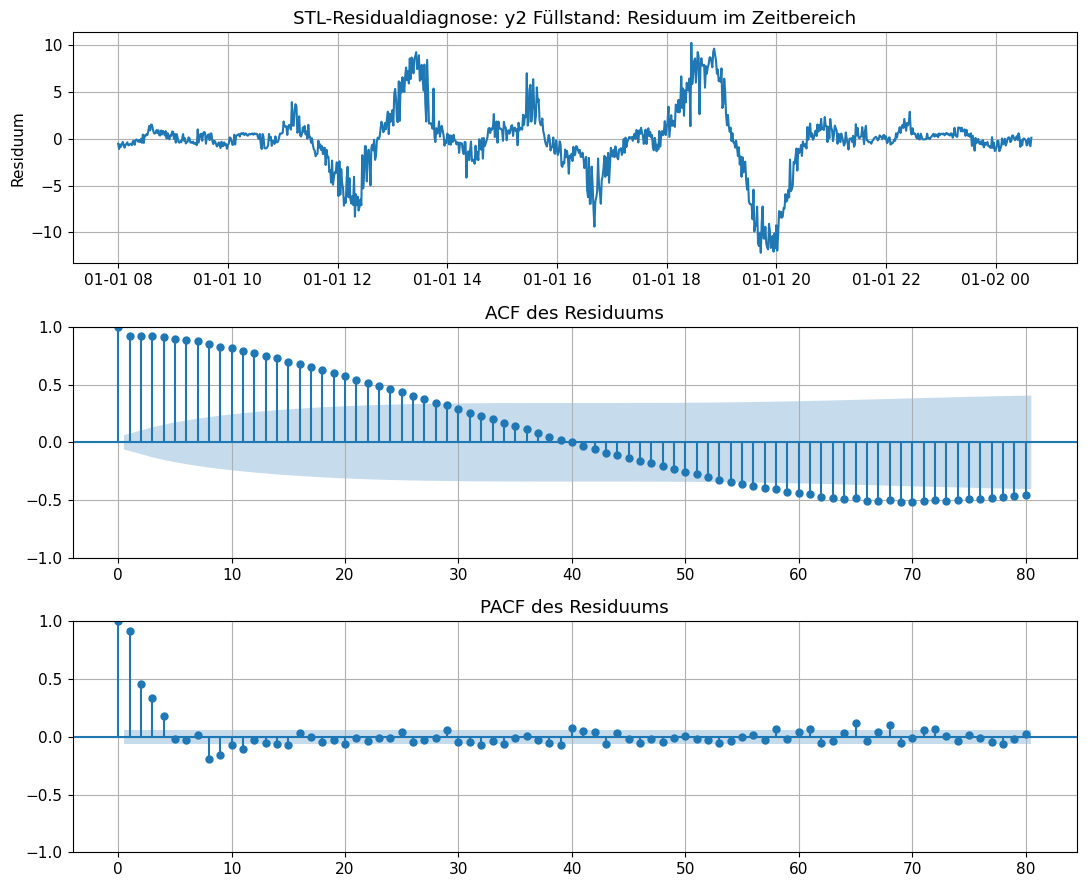

In [48]:
residual_diagnostics(
    result_y2.resid,
    max_lag=80,
    title="STL-Residualdiagnose: y2 Füllstand",
)


## 21. Vergleich der Residuen

Wenn die Residuen zweier Messgrößen noch korreliert sind, kann das bedeuten:

- Es gibt eine gemeinsame nicht entfernte Prozessstruktur.
- Eine Stellgröße oder Störgröße wurde nicht explizit modelliert.
- Die Zerlegung mit nur einer saisonalen Komponente ist nicht ausreichend.
- Das Residuum enthält mehr als nur zufälliges Rauschen.

Diagnostische Frage:

> Sind die Residuen von Temperatur und Füllstand noch miteinander gekoppelt?

Korrelation der Residuen:
                      resid_y1_temperature  resid_y2_level
resid_y1_temperature              1.000000       -0.192234
resid_y2_level                   -0.192234        1.000000


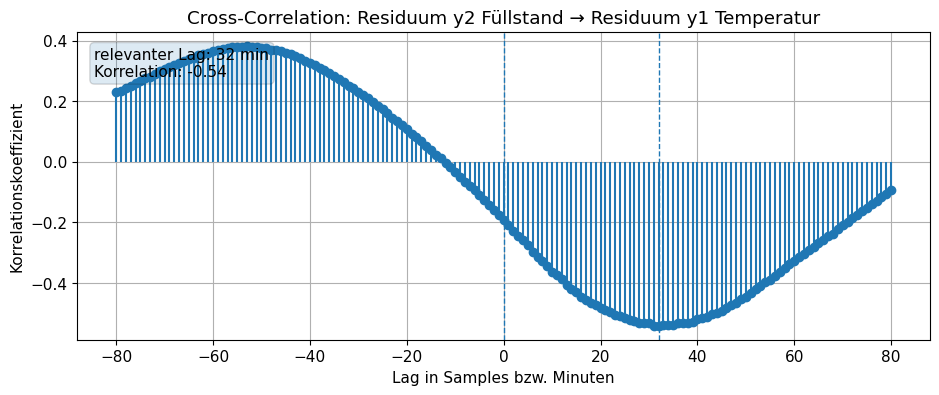

(32, -0.5412046546897771)

In [50]:
residual_df = pd.DataFrame(
    {
        "resid_y1_temperature": result_y1.resid,
        "resid_y2_level": result_y2.resid,
    }
).dropna()

print("Korrelation der Residuen:")
print(residual_df.corr())

plot_ccf(
    residual_df["resid_y2_level"],
    residual_df["resid_y1_temperature"],
    "Residuum y2 Füllstand",
    "Residuum y1 Temperatur",
    max_lag=80,
    mode="abs",
)

## 22. MSTL bei mehreren periodischen Anteilen

MSTL ist eine Erweiterung von STL für mehrere saisonale bzw. periodische Muster.

In diesem synthetischen Beispiel sind zwei periodische Störungen eingebaut:

- kurze Periode: 60 Minuten
- lange Periode: 180 Minuten

STL mit nur einer Periode kann nicht beide Anteile gleichzeitig sauber entfernen. MSTL ist hier didaktisch passend, weil die Residuen nach MSTL in der Regel strukturärmer werden sollten als nach der einfachen STL-Zerlegung.

Diagnostische Frage:

> Werden die Residuen nach MSTL strukturärmer als nach der einfachen STL-Zerlegung?


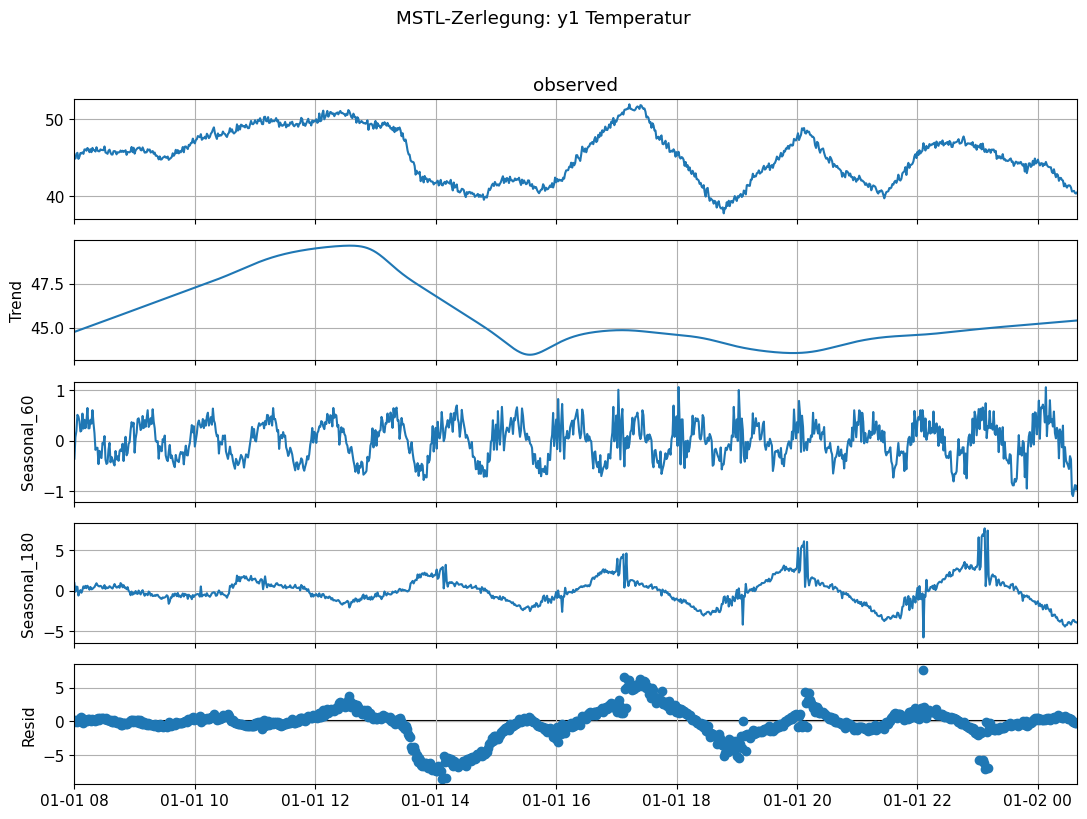

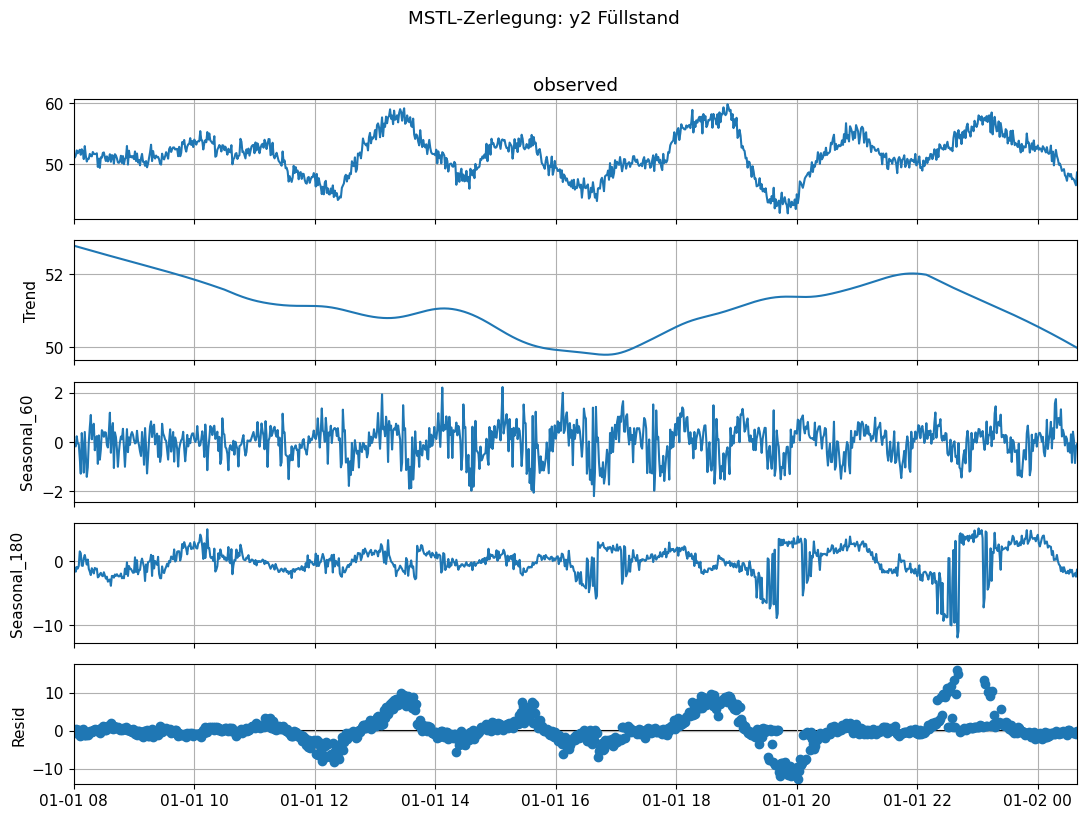

,Signal,Std,mittlere_abs_Abweichung,ACF_Lag_1,ACF_Lag_10
0,STL y1,2.462385,1.535561,0.985584,0.912726
1,MSTL y1,2.308004,1.506401,0.944356,0.860451
2,STL y2,3.335098,2.050381,0.919976,0.817869
3,MSTL y2,3.570518,2.240242,0.849163,0.676200


In [52]:
if MSTL_AVAILABLE:
    mstl_y1 = MSTL(
        df["y1_temperature_degC"],
        periods=[SHORT_CYCLE_PERIOD_SAMPLES, LONG_CYCLE_PERIOD_SAMPLES],
        stl_kwargs={"robust": True},
    )
    result_mstl_y1 = mstl_y1.fit()

    fig = result_mstl_y1.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle("MSTL-Zerlegung: y1 Temperatur", y=1.02)
    plt.tight_layout()
    plt.show()

    mstl_y2 = MSTL(
        df["y2_level_pct"],
        periods=[SHORT_CYCLE_PERIOD_SAMPLES, LONG_CYCLE_PERIOD_SAMPLES],
        stl_kwargs={"robust": True},
    )
    result_mstl_y2 = mstl_y2.fit()

    fig = result_mstl_y2.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle("MSTL-Zerlegung: y2 Füllstand", y=1.02)
    plt.tight_layout()
    plt.show()

    residual_quality = residual_quality_table(
        {
            "STL y1": result_y1.resid,
            "MSTL y1": result_mstl_y1.resid,
            "STL y2": result_y2.resid,
            "MSTL y2": result_mstl_y2.resid,
        }
    )

    display(residual_quality)

else:
    print("MSTL ist in dieser statsmodels-Installation nicht verfügbar.")
    print("Das Notebook läuft trotzdem weiter; der Abschnitt kann als theoretischer Ausblick gelesen werden.")


### Residualdiagnose nach MSTL

Die folgende Zelle wird nur ausgeführt, wenn MSTL verfügbar ist.

Erwartung:

- Die Residuen können kleiner und strukturärmer werden.
- Es können trotzdem Autokorrelationen übrig bleiben, weil Sprünge, Totzeiten und gekoppelte Prozesswirkungen nicht durch eine rein saisonale Zerlegung erklärt werden.

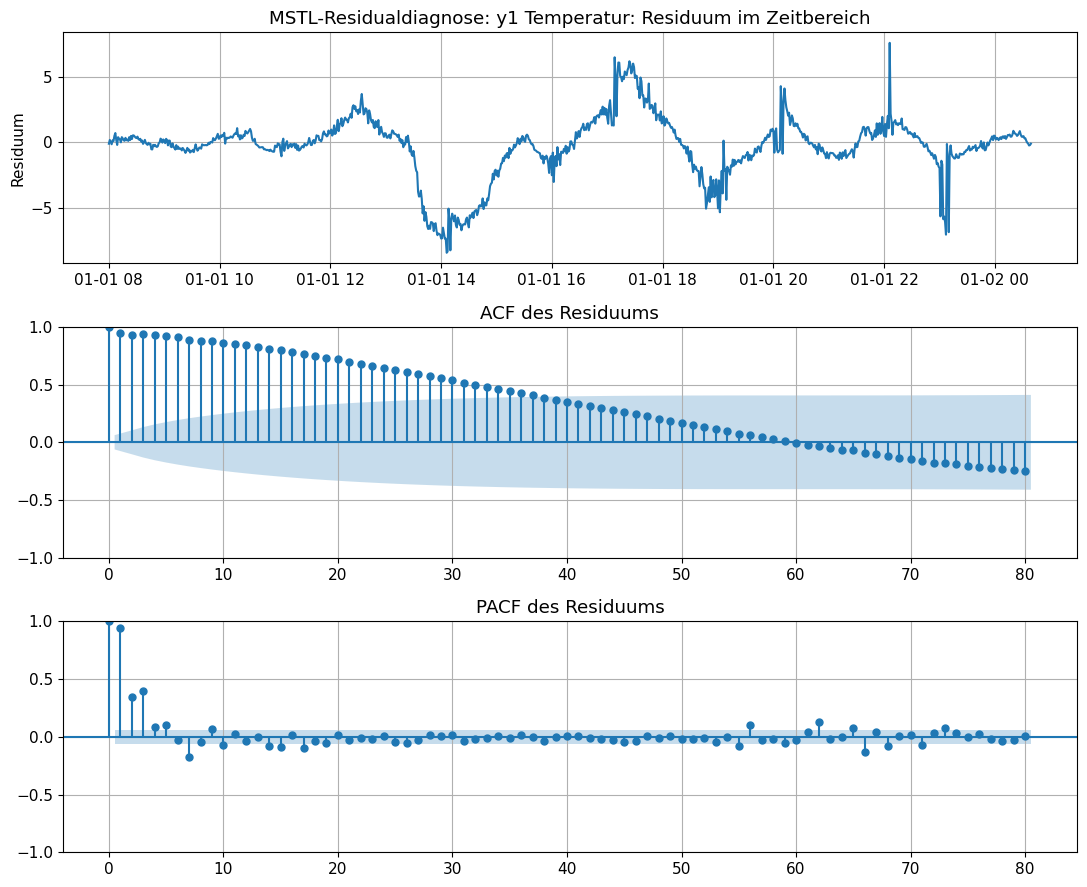

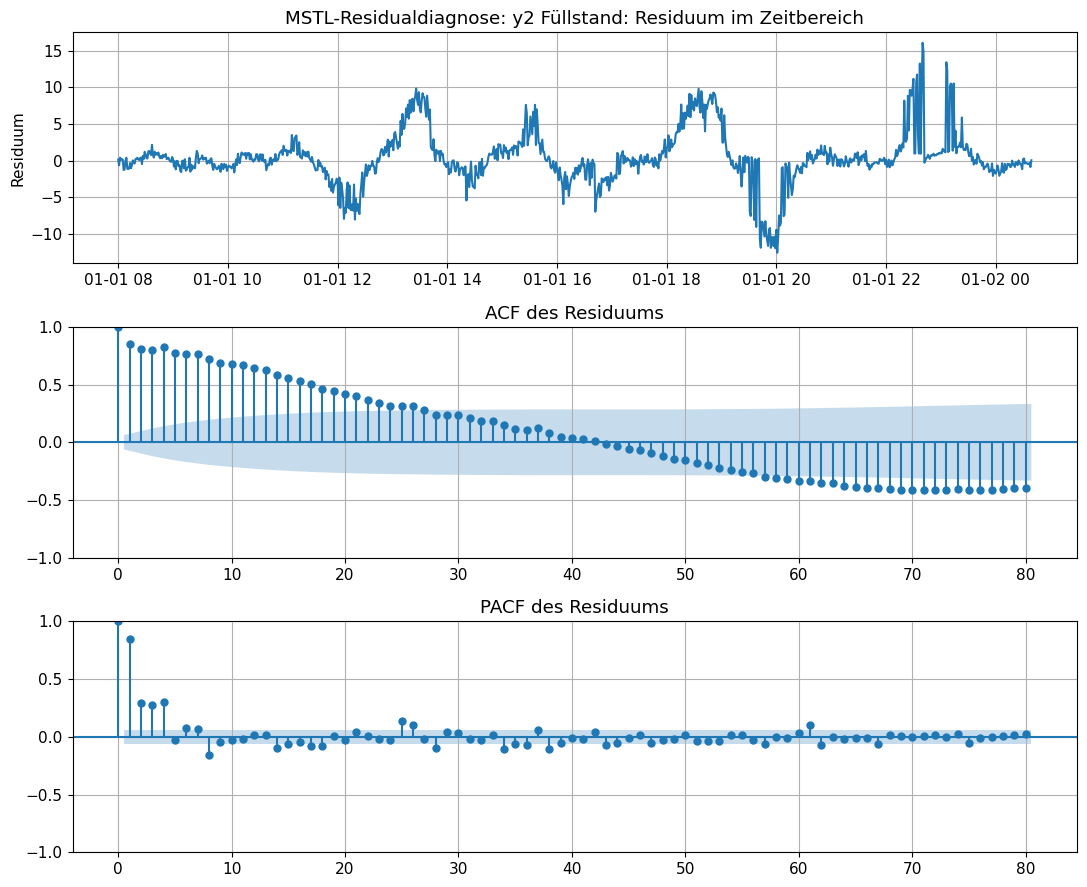

In [54]:
if MSTL_AVAILABLE:
    residual_diagnostics(
        result_mstl_y1.resid,
        max_lag=80,
        title="MSTL-Residualdiagnose: y1 Temperatur",
    )

    residual_diagnostics(
        result_mstl_y2.resid,
        max_lag=80,
        title="MSTL-Residualdiagnose: y2 Füllstand",
    )

## 23. Übungsaufgaben

Bearbeiten Sie die folgenden Aufgaben direkt im Notebook.

1. Erhöhen Sie `DELAY_U1_Y1` von 8 auf 20 Minuten.  
   Wird der veränderte Lag in der Cross-Correlation sichtbar?

2. Erhöhen Sie `TEMP_NOISE_STD`.  
   Welche Plots werden schwieriger zu interpretieren?

3. Setzen Sie `K_U2_Y1` auf 0.  
   Was passiert mit der CCF `u2 → y1` und mit der Korrelation zwischen `y1` und `y2`?

4. Vergrößern Sie `TEMP_SHORT_CYCLE_AMPLITUDE`.  
   Wird die STL-Residualdiagnose schlechter, wenn nur die lange Periode verwendet wird?

5. Ändern Sie `SHORT_CYCLE_PERIOD_MIN` von 60 auf 90 Minuten.  
   Muss auch die MSTL-Konfiguration angepasst werden?

6. Vergleichen Sie die Residuen nach STL und MSTL.  
   Welche Zerlegung entfernt mehr periodische Struktur?

7. Prüfen Sie die CCF `u1 → y2`.  
   Warum sollte hier physikalisch kein starker Zusammenhang erwartet werden?


## 24. Zusammenfassung

In diesem Notebook wurde ein einfacher offener Rührkessel als Prozessbeispiel verwendet.

Wichtige Ergebnisse:

- `u1` wirkt hauptsächlich auf die Temperatur `y1`.
- `u2` wirkt hauptsächlich auf den Füllstand `y2`.
- `u2` beeinflusst die Temperatur zusätzlich negativ, weil kalter Zulauf in den Kessel gelangt.
- Temperatur und Füllstand können korreliert sein, ohne dass eine direkte kausale Wirkung zwischen beiden Messgrößen bestehen muss.
- ACF und PACF beschreiben die Lag-Struktur einer einzelnen Zeitreihe.
- Cross-Correlation hilft bei der Analyse verzögerter Zusammenhänge zwischen zwei Zeitreihen.
- Periodogramme sind bei sprungdominierten Prozessdaten vorsichtig zu interpretieren.
- STL zerlegt eine Zeitreihe in Trend, saisonale Komponente und Residuum.
- MSTL ist nützlich, wenn mehrere periodische Muster gleichzeitig auftreten.
- Die Residualdiagnose ist wichtig, weil ein gutes Residuum möglichst wenig systematische Struktur enthalten sollte.


## Quellen und weiterführende Orientierung

- `pandas` Time Series User Guide: Zeitindex, Resampling, Rolling Windows und `shift()`
- `statsmodels` ACF/PACF-Dokumentation
- `statsmodels` STL- und MSTL-Beispiele
- `scipy.signal.periodogram`
- `scipy.signal.lombscargle`
- Hyndman & Athanasopoulos: Forecasting: Principles and Practice
- APMonitor / CBE30338: First Order Plus Dead Time und verfahrenstechnische Sprungantworten

Die Quellen dienen hier als methodische Orientierung. Das Prozessbeispiel im Notebook ist synthetisch und didaktisch vereinfacht.
